# 🔍 Implémentation Word2Vec - Modèle Avancé

Ce notebook implémente notre modèle **Word2Vec** pour la recherche d'information sur le dataset TREC-COVID.

## Objectifs
- Charger le dataset TREC-COVID
- Implémenter Word2Vec pour représenter les documents et requêtes
- Utiliser les fonctions généralistes pour la recherche et l'évaluation
- Évaluer les performances avec NDCG@10 et comparer avec TF-IDF


## 📦 1. Imports et Configuration


In [3]:
# Imports nécessaires
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
from beir.datasets.data_loader import GenericDataLoader

# Télécharger les données NLTK nécessaires
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Import our general-purpose evaluation functions
from functions import search, top_k_ideal, evaluate_single_query, evaluate_model

print("✓ Imports terminés")


c:\Users\KEBDI Lounès\Documents\Projets\env_dossierprojets\lib\site-packages\beir\datasets\data_loader.py:8: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
[nltk_data] Downloading package stopwords to C:\Users\KEBDI
[nltk_data]     Lounès\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


✓ Imports terminés


## 📂 2. Chargement des Données


In [4]:
# Chemin vers le dataset TREC-COVID
data_path = "data/trec-covid/trec-covid"

# Vérifier que le dataset existe
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset introuvable à {data_path}. Exécutez d'abord download.py")

print(f"Chargement du dataset depuis: {data_path}")


Chargement du dataset depuis: data/trec-covid/trec-covid


In [5]:
# Charger les données avec BEIR
corpus, queries, qrels = GenericDataLoader(data_path).load(split="test")

print(f"✓ Corpus chargé: {len(corpus)} documents")
print(f"✓ Requêtes chargées: {len(queries)} requêtes")
print(f"✓ Qrels chargés: {len(qrels)} jugements de pertinence")


100%|██████████| 171332/171332 [00:01<00:00, 125807.41it/s]


✓ Corpus chargé: 171332 documents
✓ Requêtes chargées: 50 requêtes
✓ Qrels chargés: 50 jugements de pertinence


In [6]:
# Afficher un exemple de document et de requête
print("Exemple de document:")
doc_id = list(corpus.keys())[0]
doc = corpus[doc_id]
print(f"ID: {doc_id}")
print(f"Titre: {doc['title'][:100]}...")
print(f"Texte: {doc['text'][:200]}...")

print("\nExemple de requête:")
query_id = list(queries.keys())[0]
query = queries[query_id]
print(f"ID: {query_id}")
print(f"Texte: {query}")


Exemple de document:
ID: ug7v899j
Titre: Clinical features of culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Ho...
Texte: OBJECTIVE: This retrospective chart review describes the epidemiology and clinical features of 40 patients with culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Hospital, J...

Exemple de requête:
ID: 1
Texte: what is the origin of COVID-19


## 🔧 3. Préparation des Données


### 3.1. Préparation et Tokenisation des Documents


In [7]:
# Préparer les documents pour Word2Vec
# On combine titre et texte, puis on tokenise
documents = []
doc_ids = []

# Charger les stop words
stop_words = set(stopwords.words('english'))

print("Tokenisation des documents...")
for doc_id, doc in corpus.items():
    # Combiner titre et texte
    full_text = f"{doc['title']} {doc['text']}"
    
    # Tokeniser et filtrer les stop words
    tokens = word_tokenize(full_text.lower())
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    
    documents.append(tokens)
    doc_ids.append(doc_id)

print(f"✓ {len(documents)} documents préparés et tokenisés")
print(f"✓ Longueur moyenne: {np.mean([len(doc) for doc in documents]):.0f} mots par document")


Tokenisation des documents...
✓ 171332 documents préparés et tokenisés
✓ Longueur moyenne: 94 mots par document


## 🎯 4. Implémentation Word2Vec


### 4.1. Création du Modèle Word2Vec

**Word2Vec** :
- Apprend des représentations vectorielles (embeddings) pour chaque mot
- Capture les relations sémantiques entre les mots
- Les mots similaires ont des vecteurs similaires
- On peut ensuite agréger les vecteurs de mots pour représenter des documents entiers


In [8]:
# Entraîner le modèle Word2Vec sur notre corpus
print("Entraînement du modèle Word2Vec...")
print("(Cela peut prendre plusieurs minutes pour 171k documents)")

model = Word2Vec(
    sentences=documents,
    vector_size=300,  # Dimension des vecteurs de mots
    window=5,  # Taille de la fenêtre de contexte
    min_count=2,  # Ignorer les mots qui apparaissent moins de 2 fois
    workers=4,  # Nombre de threads
    sg=0,  # 0 = CBOW, 1 = Skip-gram
    epochs=10  # Nombre d'itérations sur le corpus
)

print(f"✓ Modèle Word2Vec entraîné")
print(f"  - Vocabulaire: {len(model.wv)} mots")
print(f"  - Dimension des vecteurs: {model.wv.vector_size}")


Entraînement du modèle Word2Vec...
(Cela peut prendre plusieurs minutes pour 171k documents)
✓ Modèle Word2Vec entraîné
  - Vocabulaire: 105771 mots
  - Dimension des vecteurs: 300


### 4.2. Création des Vecteurs de Documents


In [9]:
# Fonction pour créer un vecteur de document à partir des vecteurs de mots
def document_to_vector(tokens, model):
    """
    Convertit un document (liste de tokens) en un vecteur unique.
    Utilise la moyenne des vecteurs de mots (moyenne simple).
    """
    word_vectors = []
    for token in tokens:
        if token in model.wv:
            word_vectors.append(model.wv[token])
    
    if len(word_vectors) == 0:
        # Si aucun mot n'est dans le vocabulaire, retourner un vecteur de zéros
        return np.zeros(model.wv.vector_size)
    
    # Retourner la moyenne des vecteurs de mots
    return np.mean(word_vectors, axis=0)

# Créer les vecteurs pour tous les documents
print("Création des vecteurs de documents...")
doc_vectors = []

for i, tokens in enumerate(documents):
    if (i + 1) % 10000 == 0:
        print(f"  Traitement document {i+1}/{len(documents)}...")
    doc_vector = document_to_vector(tokens, model)
    doc_vectors.append(doc_vector)

# Convertir en numpy array
doc_vectors = np.array(doc_vectors)

print(f"\n✓ Vecteurs de documents créés")
print(f"  - Forme de la matrice: {doc_vectors.shape}")
print(f"  - Dimension des vecteurs: {doc_vectors.shape[1]}")


Création des vecteurs de documents...
  Traitement document 10000/171332...
  Traitement document 20000/171332...
  Traitement document 30000/171332...
  Traitement document 40000/171332...
  Traitement document 50000/171332...
  Traitement document 60000/171332...
  Traitement document 70000/171332...
  Traitement document 80000/171332...
  Traitement document 90000/171332...
  Traitement document 100000/171332...
  Traitement document 110000/171332...
  Traitement document 120000/171332...
  Traitement document 130000/171332...
  Traitement document 140000/171332...
  Traitement document 150000/171332...
  Traitement document 160000/171332...
  Traitement document 170000/171332...

✓ Vecteurs de documents créés
  - Forme de la matrice: (171332, 300)
  - Dimension des vecteurs: 300


### 4.3. Création d'un Vectorizer Compatible avec `search()`


In [10]:
# Créer une classe vectorizer pour Word2Vec compatible avec la fonction search()
class Word2VecVectorizer:
    """
    Vectorizer Word2Vec compatible avec la fonction search() de functions.py
    """
    def __init__(self, model):
        self.model = model
        self.stop_words = set(stopwords.words('english'))
    
    def transform(self, texts):
        """
        Transforme une liste de textes en vecteurs.
        Args:
            texts: Liste de chaînes de caractères
        Returns:
            Array numpy de forme (n_texts, vector_size)
        """
        vectors = []
        for text in texts:
            tokens = word_tokenize(text.lower())
            tokens = [token for token in tokens if token.isalpha() and token not in self.stop_words]
            doc_vector = document_to_vector(tokens, self.model)
            vectors.append(doc_vector)
        return np.array(vectors)

# Créer le vectorizer
vectorizer = Word2VecVectorizer(model)

print("✓ Vectorizer Word2Vec créé")


✓ Vectorizer Word2Vec créé


## 🔍 5. Recherche de Documents Pertinents


### 5.1. Test de Recherche sur une Requête

Nous utilisons la fonction généraliste `search()` de `functions.py` qui fonctionne avec n'importe quel vectorizer.


In [11]:
# Tester la fonction search() sur la première requête
test_query_id = list(queries.keys())[0]
test_query_text = queries[test_query_id]

print(f"Requête test: {test_query_id}")
print(f"Texte: {test_query_text}\n")

# Utiliser la fonction généraliste search()
results = search(
    query_text=test_query_text,
    doc_vectors=doc_vectors,
    doc_ids=doc_ids,
    vectorizer=vectorizer,
    top_k=10
)

print("Top 10 documents trouvés:")
for i, (doc_id, score) in enumerate(results, 1):
    doc = corpus[doc_id]
    print(f"{i}. Doc {doc_id} (score: {score:.4f})")
    print(f"   Titre: {doc['title'][:80]}...")
    print()


Requête test: 1
Texte: what is the origin of COVID-19

Top 10 documents trouvés:
1. Doc beguhous (score: 0.7697)
   Titre: The proximal origin of SARS-CoV-2...

2. Doc jkejiuf2 (score: 0.7546)
   Titre: Coronaviruses: origin and evolution...

3. Doc v9f5jck9 (score: 0.6713)
   Titre: Early evolution and the origin of eukaryotes...

4. Doc a7w6lael (score: 0.6580)
   Titre: Origin of SARS remains a mystery...

5. Doc ze73ajsk (score: 0.6527)
   Titre: Commentary: Origin and evolution of pathogenic coronaviruses...

6. Doc dv9m19yk (score: 0.6368)
   Titre: [What is the origin of SARS-CoV-2?]...

7. Doc pl48ev5o (score: 0.6271)
   Titre: Origin and evolution of the 2019 novel coronavirus...

8. Doc h8ahn8fw (score: 0.6271)
   Titre: Origin and Evolution of the 2019 Novel Coronavirus...

9. Doc 4ilpph77 (score: 0.6198)
   Titre: Probable Pangolin Origin of SARS-CoV-2 Associated with the COVID-19 Outbreak...

10. Doc 6foz003n (score: 0.5805)
   Titre: Diversity of Coronaviruses in Bats: In

### 5.2. Comparaison avec le Top 10 Idéal

Comparons les résultats du modèle avec le top 10 idéal basé sur les Qrels.


In [12]:
# Comparer les résultats du modèle avec le top 10 idéal
test_query_id = list(queries.keys())[0]
test_query_text = queries[test_query_id]

# Obtenir les résultats du modèle
model_results = search(
    query_text=test_query_text,
    doc_vectors=doc_vectors,
    doc_ids=doc_ids,
    vectorizer=vectorizer,
    top_k=10
)

# Obtenir le top 10 idéal
ideal_results = top_k_ideal(
    query_id=test_query_id,
    qrels=qrels,
    top_k=10
)

print("=" * 80)
print(f"COMPARAISON POUR LA REQUÊTE {test_query_id}")
print(f"Texte: {test_query_text}")
print("=" * 80)

print("\n📊 TOP 10 RETOURNÉ PAR LE MODÈLE Word2Vec:")
print("-" * 80)
for i, (doc_id, w2v_score) in enumerate(model_results, 1):
    relevance = qrels.get(test_query_id, {}).get(doc_id, 0)
    doc = corpus[doc_id]
    print(f"{i:2d}. Doc {doc_id} | Score Word2Vec: {w2v_score:.4f} | Pertinence réelle: {relevance}")
    print(f"    Titre: {doc['title'][:70]}...")

print("\n✅ TOP 10 IDÉAL (selon les Qrels):")
print("-" * 80)
for i, (doc_id, relevance_score) in enumerate(ideal_results, 1):
    doc = corpus[doc_id]
    print(f"{i:2d}. Doc {doc_id} | Score de pertinence: {relevance_score}")
    print(f"    Titre: {doc['title'][:70]}...")

# Calculer le score NDCG@10 pour cette requête avec evaluate_single_query
ndcg_score = evaluate_single_query(
    query_id=test_query_id,
    model_results=model_results,
    qrels=qrels,
    k=10
)
print(f"\n📈 Score NDCG@10 pour cette requête: {ndcg_score:.4f}")


COMPARAISON POUR LA REQUÊTE 1
Texte: what is the origin of COVID-19

📊 TOP 10 RETOURNÉ PAR LE MODÈLE Word2Vec:
--------------------------------------------------------------------------------
 1. Doc beguhous | Score Word2Vec: 0.7697 | Pertinence réelle: 2
    Titre: The proximal origin of SARS-CoV-2...
 2. Doc jkejiuf2 | Score Word2Vec: 0.7546 | Pertinence réelle: 2
    Titre: Coronaviruses: origin and evolution...
 3. Doc v9f5jck9 | Score Word2Vec: 0.6713 | Pertinence réelle: 0
    Titre: Early evolution and the origin of eukaryotes...
 4. Doc a7w6lael | Score Word2Vec: 0.6580 | Pertinence réelle: 0
    Titre: Origin of SARS remains a mystery...
 5. Doc ze73ajsk | Score Word2Vec: 0.6527 | Pertinence réelle: 1
    Titre: Commentary: Origin and evolution of pathogenic coronaviruses...
 6. Doc dv9m19yk | Score Word2Vec: 0.6368 | Pertinence réelle: 1
    Titre: [What is the origin of SARS-CoV-2?]...
 7. Doc pl48ev5o | Score Word2Vec: 0.6271 | Pertinence réelle: 2
    Titre: Origin and ev

### 5.3. Recherche sur Toutes les Requêtes


In [13]:
# Rechercher les documents pertinents pour toutes les requêtes
print("Recherche sur toutes les requêtes...")
print(f"(Traitement de {len(queries)} requêtes)\n")

# Dictionnaire pour stocker tous les résultats : {query_id: [(doc_id, score), ...]}
all_model_results = {}

for i, (query_id, query_text) in enumerate(queries.items(), 1):
    if i % 10 == 0:
        print(f"  Traitement requête {i}/{len(queries)}...")
    
    # Rechercher les top 10 documents avec la fonction généraliste
    results = search(
        query_text=query_text,
        doc_vectors=doc_vectors,
        doc_ids=doc_ids,
        vectorizer=vectorizer,
        top_k=10
    )
    
    all_model_results[query_id] = results

print(f"\n✓ Recherche terminée pour toutes les requêtes")


Recherche sur toutes les requêtes...
(Traitement de 50 requêtes)

  Traitement requête 10/50...
  Traitement requête 20/50...
  Traitement requête 30/50...
  Traitement requête 40/50...
  Traitement requête 50/50...

✓ Recherche terminée pour toutes les requêtes


## 📊 6. Évaluation avec NDCG@10


In [14]:
# Évaluer le modèle sur toutes les requêtes avec evaluate_model
evaluation_results = evaluate_model(
    queries=queries,
    all_model_results=all_model_results,
    qrels=qrels,
    k=10
)


EVALUATION SUMMARY
Mean NDCG@10: 0.6099
Min NDCG@10: 0.0000
Max NDCG@10: 1.0000
Std NDCG@10: 0.3301
Number of queries: 50


### 6.1. Distribution des Scores


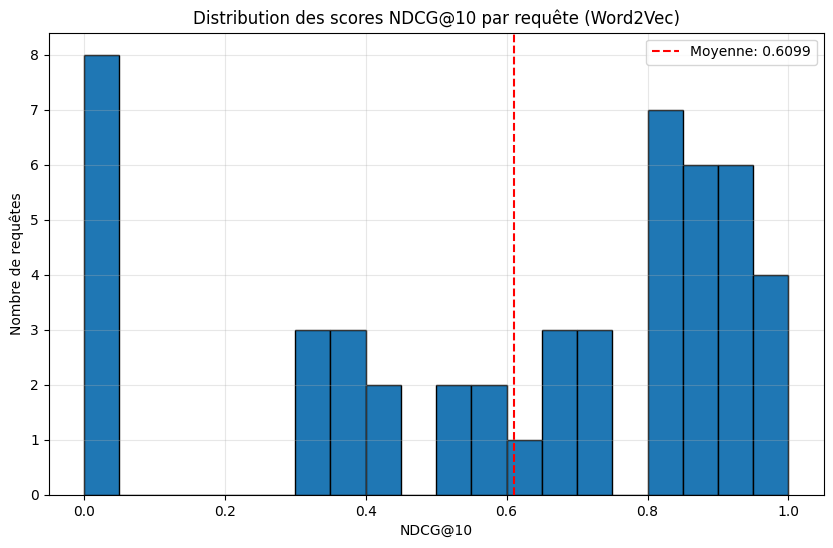

In [15]:
# Afficher la distribution des scores NDCG@10
ndcg_scores = evaluation_results['scores']

plt.figure(figsize=(10, 6))
plt.hist(list(ndcg_scores.values()), bins=20, edgecolor='black')
plt.xlabel('NDCG@10')
plt.ylabel('Nombre de requêtes')
plt.title('Distribution des scores NDCG@10 par requête (Word2Vec)')
plt.axvline(evaluation_results['mean_score'], color='r', linestyle='--', 
            label=f'Moyenne: {evaluation_results["mean_score"]:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 📈 7. Analyse des Résultats


In [16]:
# Afficher les meilleures et pires requêtes
ndcg_df = pd.DataFrame([
    {'query_id': qid, 'ndcg@10': score} 
    for qid, score in ndcg_scores.items()
]).sort_values('ndcg@10', ascending=False)

print("Top 5 meilleures requêtes:")
print(ndcg_df.head())
print("\nTop 5 pires requêtes:")
print(ndcg_df.tail())


Top 5 meilleures requêtes:
   query_id   ndcg@10
38       39  1.000000
37       38  0.999121
20       21  0.973418
26       27  0.954181
15       16  0.949666

Top 5 pires requêtes:
   query_id  ndcg@10
1         2      0.0
33       34      0.0
22       23      0.0
40       41      0.0
49       50      0.0


In [17]:
# Analyser une requête avec un bon score
best_query_id = ndcg_df.iloc[0]['query_id']
best_query_text = queries[best_query_id]
best_ndcg = ndcg_df.iloc[0]['ndcg@10']

print(f"\nRequête avec le meilleur NDCG@10 ({best_ndcg:.4f}):")
print(f"ID: {best_query_id}")
print(f"Texte: {best_query_text}\n")

# Obtenir les résultats du modèle pour cette requête depuis all_model_results
model_results = all_model_results[best_query_id]

print("Top 5 documents retournés:")
for i, (doc_id, score) in enumerate(model_results[:5], 1):
    doc = corpus[doc_id]
    relevance = qrels.get(best_query_id, {}).get(doc_id, 0)
    print(f"{i}. Doc {doc_id} (score Word2Vec: {score:.4f}, pertinence réelle: {relevance})")
    print(f"   Titre: {doc['title'][:80]}...")
    print()



Requête avec le meilleur NDCG@10 (1.0000):
ID: 39
Texte: What is the mechanism of cytokine storm syndrome on the COVID-19?

Top 5 documents retournés:
1. Doc m6kxxio1 (score Word2Vec: 0.8501, pertinence réelle: 2)
   Titre: Cytokine storm syndrome in severe COVID-19...

2. Doc 9408n63a (score Word2Vec: 0.8156, pertinence réelle: 2)
   Titre: Preventing cytokine storm syndrome in COVID-19 using α-1 adrenergic receptor ant...

3. Doc 5c9f4m2f (score Word2Vec: 0.7923, pertinence réelle: 2)
   Titre: Tocilizumab: A Therapeutic Option for the Treatment of Cytokine Storm Syndrome i...

4. Doc a1y0enrg (score Word2Vec: 0.7887, pertinence réelle: 2)
   Titre: mTORC inhibitor Sirolimus deprograms monocytes in “cytokine storm” in SARS-CoV2 ...

5. Doc xr0wx0fu (score Word2Vec: 0.7817, pertinence réelle: 2)
   Titre: Preventing cytokine storm syndrome in COVID-19 using α-1 adrenergic receptor ant...



## 💾 8. Sauvegarde des Résultats


In [18]:
# Sauvegarder les résultats pour comparaison avec TF-IDF
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# Sauvegarder les scores NDCG
ndcg_scores = evaluation_results['scores']
with open(f"{results_dir}/word2vec_ndcg_scores.json", "w", encoding="utf-8") as f:
    json.dump(ndcg_scores, f, indent=2)

# Sauvegarder le résumé
summary = {
    "model": "Word2Vec",
    "mean_ndcg@10": evaluation_results['mean_score'],
    "min_ndcg@10": evaluation_results['min_score'],
    "max_ndcg@10": evaluation_results['max_score'],
    "std_ndcg@10": evaluation_results['std_score'],
    "num_queries": evaluation_results['num_queries'],
    "num_documents": len(doc_ids)
}

with open(f"{results_dir}/word2vec_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"✓ Résultats sauvegardés dans {results_dir}/")
print(f"  - word2vec_ndcg_scores.json")
print(f"  - word2vec_summary.json")


✓ Résultats sauvegardés dans results/
  - word2vec_ndcg_scores.json
  - word2vec_summary.json


## ✅ Conclusion

Nous avons implémenté avec succès notre modèle **Word2Vec** en utilisant les fonctions généralistes :

- ✅ Corpus tokenisé et préparé pour Word2Vec
- ✅ Modèle Word2Vec entraîné sur le corpus
- ✅ Vecteurs de documents créés
- ✅ Recherche effectuée avec la fonction généraliste `search()`
- ✅ Évaluation avec NDCG@10 utilisant `evaluate_model()` et `evaluate_single_query()`
- ✅ Score obtenu et sauvegardé

**Avantages de l'approche généraliste :**
- Code réutilisable avec TF-IDF ou autres modèles
- Fonctions testées et maintenables
- Facile à comparer différents modèles

**Prochaines étapes :**
- Comparer les performances Word2Vec vs TF-IDF
- Tester avec des modèles Word2Vec pré-entraînés (ex: Google News)
- Expérimenter avec d'autres méthodes d'agrégation (moyenne pondérée, etc.)
